# Diferenciación numérica

Por definición, la derivada de f(x) en un valor x es:

$$f'(x)=\lim_{h \rightarrow 0} \frac{f(x+h) - f(x)}{h}$$

siempre y cuando el limite exista.

El teorema de Taylor dice que si es $f$ es dos veces diferenciable, entonces:

$$f(x) = f(a) + f'(a)(x-a) + \frac{f''(a)}{2}(x-a)^2+...+\frac{f^{(n)}}{n!}(x-a)^n$$

$$f(x) = \sum_{n = 0}^{\inf} \frac{f^{(n)}(a)}{n!}(x-a)^n$$

Si realizamos la serie para f(x+h) alrededor de x para una función dos veces diferenciable:

$$ f(x + h) = f(x) + f'(x)(x + h - x) + \frac{f''(x)}{2}(x + h - x)^2 $$

$$f(x+h)=f(x) + hf'(x) + \frac{h^2}{2}f''(c)$$

Donde c se encuentra entre x y x + h

# Fórmula de la diferencia hacia adelante de dos puntos

$$f'(x) = \frac{f(x+h) - f(x)}{h} - \frac{h}{2}f''(c)$$

Donde c se encuentra entre x y x + h

Una aproximación para la derivada es:

$$f'(x) \approx \frac{f(x+h) - f(x)}{h}$$

El segundo término $\frac{h}{2}f''(c)$ se denomina el error, como se puede ver proporcional al incremento h, disminuir h disminuye el error. La fórmula de diferencia hacia adelante es una aproximación de primer orden. Si el error es de $O(h^n)$ se considera una aproximación de orden n.


aprox          exacta         error          
-0.2487562189  -0.2500000000  1.243781e-03   
Cota superior del error: 1.250000e-02
Cota inferior del error: 1.079797e-02


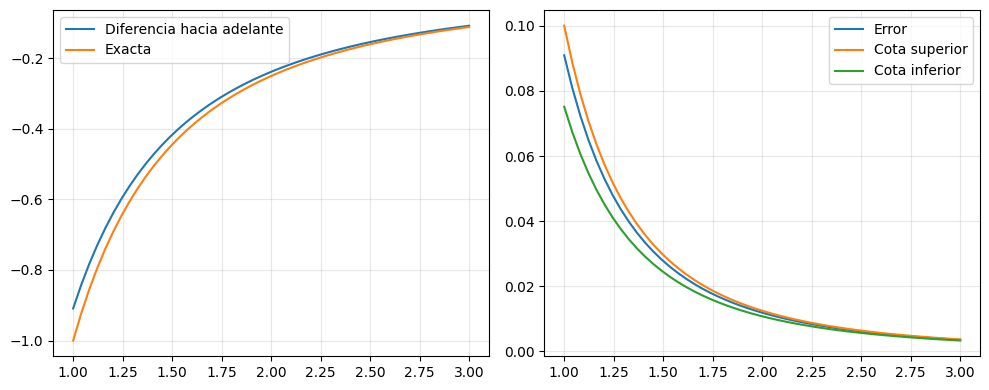

In [15]:
# Diferencia hacia adelante
import numpy as np
import matplotlib.pyplot as plt

def diferencia_hacia_adelante(f, x, h):
    return (f(x + h) - f(x))/h

def f(x):
    return 1/x

def df(x):
    return -x**(-2)

def cota_error(c, h):
    return (h)*(c**(-3))

aprox = diferencia_hacia_adelante(f, 2, 0.01)
exacta = df(2)
error = np.abs(exacta - aprox)
print(f"{'aprox':<{15}}{'exacta':<{15}}{'error':<{15}}")
print(f"{aprox:<{15}.10f}{exacta:<{15}.10f}{error:<{15}e}")

cota_i = cota_error(2.1, 0.1)
cota_s = cota_error(2, 0.1)
print(f"Cota superior del error: {cota_s:e}")
print(f"Cota inferior del error: {cota_i:e}")

x = np.linspace(1,3,50)
aprox = diferencia_hacia_adelante(f, x, 0.1)
exacta = df(x)
error = np.abs(exacta - aprox)
cota_i = cota_error(x + 0.1,0.1)
cota_s = cota_error(x,0.1)

fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(x, aprox, label = 'Diferencia hacia adelante')
ax[0].plot(x, exacta, label = 'Exacta')
ax[0].legend()
ax[0].grid(alpha = 0.3)

ax[1].plot(x, error, label = 'Error')
ax[1].plot(x, cota_s, label = 'Cota superior')
ax[1].plot(x, cota_i, label = 'Cota inferior')
ax[1].legend()
ax[1].grid(alpha = 0.3)
plt.tight_layout()
plt.show()

# Fórmula de la diferencia centrada de tres puntos

Para deducir esta fórmula se hace uso de una aproximación de Taylor para una función $f$ tres veces diferenciable:

$$f(x+h) = f(x) + hf'(x) + \frac{h^2}{2}f''(x) + \frac{h^3}{6}f'''(c_1)$$

$$f(x-h) = f(x) - hf'(x) + \frac{h^2}{2}f''(x) - \frac{h^3}{6}f'''(c_2)$$

$$f(x+h) - f(x-h) = 2hf'(x) + \frac{h^3}{6}f'''(c_1) + \frac{h^3}{6}f'''(c_2)$$

$$f(x+h) - f(x-h) = 2h(f'(x) + \frac{h^2}{12}f'''(c_1) + \frac{h^2}{12}f'''(c_2))$$

$$f'(x) = \frac{f(x+h) - f(x-h)}{2h} -  \frac{h^2}{12}f'''(c_1)  -  \frac{h^2}{12}f'''(c_2) $$

Y por el teorema del valor intermedio:

$$f'(x) = \frac{f(x+h) - f(x-h)}{2h} -  \frac{h^2}{6}f'''(c) $$

Donde c se encuentra entre $x - h \le c \le x + h$



aprox          exacta         error          
-0.2506265664  -0.2500000000  6.265664e-04   
Cota superior del error: 7.673360e-04
Cota inferior del error: 5.141890e-04


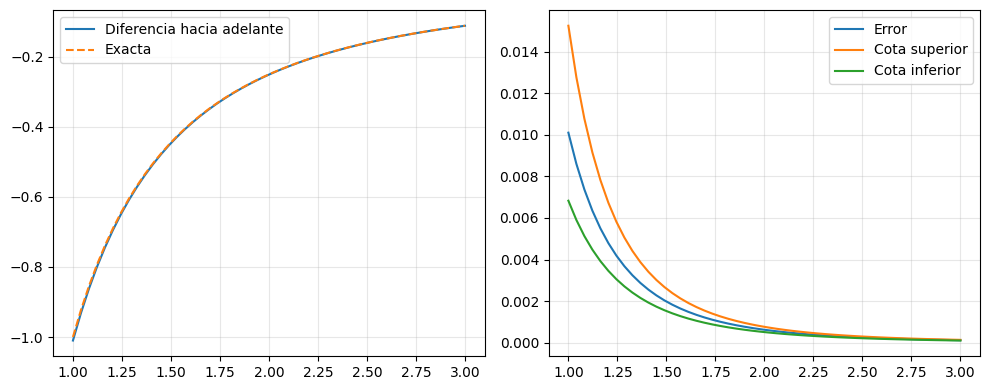

In [9]:
# Diferencia centrada de 3 puntos

import numpy as np

def diferencia_centrada(f, x, h):
    return (f(x + h) - f(x - h))/(2*h)

def f(x):
    return 1/x

def df(x):
    return -x**(-2)

def cota_error(c, h):
    return (h**2)*(c**(-4))

aprox = diferencia_centrada(f, 2, 0.1)
exacta = df(2)
error = np.abs(exacta - aprox)
print(f"{'aprox':<{15}}{'exacta':<{15}}{'error':<{15}}")
print(f"{aprox:<{15}.10f}{exacta:<{15}.10f}{error:<{15}e}")

cota_i = cota_error(2.1, 0.1)
cota_s = cota_error(1.9, 0.1)
print(f"Cota superior del error: {cota_s:e}")
print(f"Cota inferior del error: {cota_i:e}")

x = np.linspace(1,3,50)
aprox = diferencia_centrada(f, x, 0.1)
exacta = df(x)
error = np.abs(exacta - aprox)
cota_s = cota_error(x - 0.1, 0.1)
cota_i = cota_error(x + 0.1, 0.1)

fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(x, aprox, label = 'Diferencia hacia adelante')
ax[0].plot(x, exacta, label = 'Exacta', ls = '--')
ax[0].legend()
ax[0].grid(alpha = 0.3)

ax[1].plot(x, error, label = 'Error')
ax[1].plot(x, cota_s, label = 'Cota superior')
ax[1].plot(x, cota_i, label = 'Cota inferior')
ax[1].legend()
ax[1].grid(alpha = 0.3)
plt.tight_layout()
plt.show()

# Fórmula de la diferencia centrada de 3 puntos para la segunda derivada

Se parte de la serie de Taylor para una función 4 veces diferenciable:

$$x(x+h) = f(x) + hf'(x) + \frac{h^2}{2}f''(x) + \frac{h^3}{6}f'''(x) + \frac{h^4}{24}f^{(4)}(c_1)$$

$$x(x-h) = f(x) - hf'(x) + \frac{h^2}{2}f''(x) - \frac{h^3}{6}f'''(x) + \frac{h^4}{24}f^{(4)}(c_2)$$

$$f(x + h) + f(x - h) - 2f(x) = h^2f''(x) + \frac{h^4}{24}f^{(4)}(c_1) + \frac{h^4}{24}f^{(4)}(c_2)   $$

$$f(x + h) + f(x - h) - 2f(x) = h^2(f''(x) + \frac{h^2}{12}f^{(4)}(c)) $$

$$f''(x) = \frac{f(x + h) + f(x - h) - 2f(x)}{h^2} - \frac{h^2}{12}f^{(4)}(c)  $$

Para alguna c entre x - h y x + h

aprox          exacta         error          
480.6000000000 480.0000000000 6.000000e-01   
Cota superior del error: 6.300000e-01
Cota inferior del error: 5.700000e-01


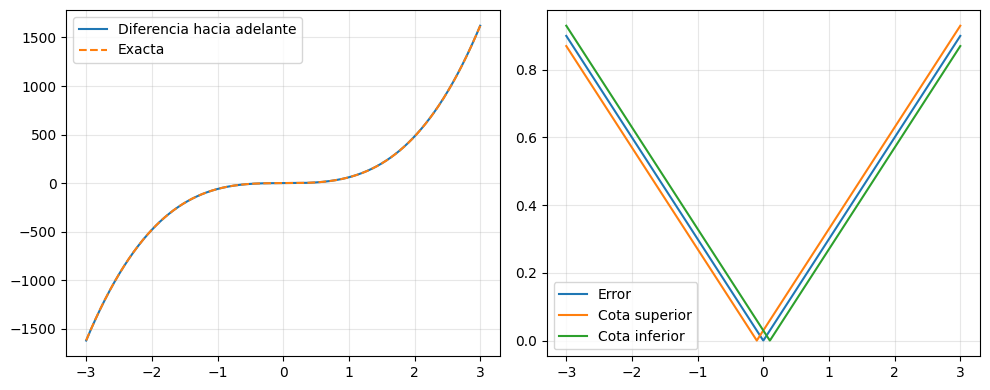

In [7]:

def segunda_derivada_centrada(f, x, h):
    return (f(x+h) + f(x-h) - 2*f(x))/h**2

def f(x):
    return 3*x**5 + 2*x

def df2(x):
    return 60*x**3


def cota_error(c, h):
    return np.abs(360*c*(h**2/12))


aprox = segunda_derivada_centrada(f, 2, 0.1)
exacta = df2(2)
error = np.abs(exacta - aprox)
cota_s = cota_error(2.1, 0.1)
cota_i = cota_error(1.9, 0.1)

print(f"{'aprox':<{15}}{'exacta':<{15}}{'error':<{15}}")
print(f"{aprox:<{15}.10f}{exacta:<{15}.10f}{error:<{15}e}")
print(f"Cota superior del error: {cota_s:e}")
print(f"Cota inferior del error: {cota_i:e}")

x = np.linspace(-3,3,1000)
aprox = segunda_derivada_centrada(f, x, 0.1)
exacta = df2(x)
error = np.abs(exacta - aprox)
cota_s = cota_error(x + 0.1, 0.1)
cota_i = cota_error(x - 0.1, 0.1)

fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(x, aprox, label = 'Diferencia hacia adelante')
ax[0].plot(x, exacta, label = 'Exacta', ls = '--')
ax[0].legend()
ax[0].grid(alpha = 0.3)

ax[1].plot(x, error, label = 'Error')
ax[1].plot(x, cota_s, label = 'Cota superior')
ax[1].plot(x, cota_i, label = 'Cota inferior')
ax[1].legend()
ax[1].grid(alpha = 0.3)
plt.tight_layout()
plt.show()



# Error de redondeo

Todas las fórmulas anteriores, rompen la regla de no restar números iguales. Sin embargo, esto es imposible de evitar. Considere el siguiente ejemplo

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.exp(x)

def df(x):
    return np.exp(x)

h = 10.0**(-np.arange(1,10))

aprox1 = diferencia_centrada(f, 0, h)
exacta = df(0)
aprox2 = diferencia_hacia_adelante(f,0,h)
error1 = np.abs(exacta - aprox1)
error2 = np.abs(exacta - aprox2)

print(f"{'h':<{15}}{'centrada':<{15}}{'error':<{15}}{'hacia adelante':<{15}}{'error':<{15}}")
for i in range(h.shape[0]):
    print(f"{h[i]:<{15}e}{aprox1[i]:<{15}.10f}{error1[i]:<{15}e}{aprox2[i]:<{15}.10f}{error2[i]:<{15}e}")



h              centrada       error          hacia adelante error          
1.000000e-01   1.0016675002   1.667500e-03   1.0517091808   5.170918e-02   
1.000000e-02   1.0000166667   1.666675e-05   1.0050167084   5.016708e-03   
1.000000e-03   1.0000001667   1.666667e-07   1.0005001667   5.001667e-04   
1.000000e-04   1.0000000017   1.666890e-09   1.0000500017   5.000167e-05   
1.000000e-05   1.0000000000   1.210232e-11   1.0000050000   5.000007e-06   
1.000000e-06   1.0000000000   2.675549e-11   1.0000005000   4.999622e-07   
1.000000e-07   0.9999999995   5.263558e-10   1.0000000494   4.943368e-08   
1.000000e-08   0.9999999995   5.263558e-10   0.9999999939   6.077471e-09   
1.000000e-09   1.0000000272   2.722922e-08   1.0000000827   8.274037e-08   


Al inicio, el error decrece a medida que h disminuye, siguiendo los errores esperados $O(h)$ y $O(h^2)$ para la diferencia hacia adelante de dos puntos y centrada de 3 puntos. Luego de cierto orden de magnitud, el error vuelve a crecer. El problema es el redondeo en la aritmética de punto flotante y la perdida de cifras significativas. Ambas fórmulas restan números casi iguales y pierden digitos significativos, además está siendo dividido entre un número pequeño.

Definamos $f^*(x+h)$ como la versión de punto de flotante de la entrada $f(x+h)$, lo mismo para $f(x-h)$. Entonces:

$$f'(x)_{correcta}-f'(x)_{máquina} = f'(x) - \frac{f^*(x+h)-f^*(x-h)}{2h}$$
$$=f'(x) - \frac{f(x+h)+\epsilon_{1}-(f(x-h)+\epsilon_2)}{2h}$$
$$=\left( f'(x) - \frac{f(x+h)-f(x-h)}{2h} \right) + \frac{\epsilon_2 - \epsilon_1}{2h}$$

$$=(f'(x)_{correcta} - f'(x)_{formula}) + error_{redondeo}$$

El error total es suma del error de truncamiento, la diferencia entre la derivada correcta y la fórmula de aproximación y el error de redondeo.

$$\lvert \frac{\epsilon_2 - \epsilon_1}{2h} \rvert \le \frac{2\epsilon_{maq}}{2h}=\frac{\epsilon_{maq}}{h}$$

Por lo tanto el error es:

$$E(h) = \frac{h^2}{6}f'''(c) + \frac{\epsilon_{maq}}{h}$$

Donde c se encuentra entre x - h y x + h (para la fórmula centrada)

Si queremos buscar el mínimo de la función error:

$$0 = E'(h) = - \frac{\epsilon_{maq}}{h^2} + \frac{M}{3}h$$

$$h = (3\epsilon_{maq} /M)^{1/3}$$

Para nuestro problema anterior por ejemplo.

$$h = (3\epsilon_{maq} /e^0)^{1/3} = 8.73x10^{-6}$$

Tener en cuenta en cuenta que es una cota superior del error



# Extrapolación de Richardson

Suponga que se presenta una fórmula $F(h)$ de orden n para aproximar una cantidad dada Q. El orden significa que:

$$Q = F(h) + kh^n$$

Por ejemplo: 

$$f'(x) = \frac{f(x+h) - f(x-h)}{2h} -  \frac{h^2}{6}f'''(c_h) $$

Donde $c_h$ se encuentra entre $x$ y $x + h$ pero depende de $h$. $c_h$ no es constante pero si $f$ es suave y $h$ no es demasiado grande $$\frac{f'''(c_h)}{6} \approx \frac{f'''(x)}{6}$$.

Usando algebra se puede convertir una fórmula de orden n en una de orden superior

$$Q = F(\frac{h}{2}) + K(\frac{h}{2})^n$$
$$Q = F(\frac{h}{2}) + K\frac{h^n}{2^n}$$
$$2^nQ = 2^nF(\frac{h}{2}) + Kh^n$$

Si restamos esta nueva ecuación a:

$$Q = F(h) + kh^n$$

$$Q(1-2^n)=F(h)-2^nF(\frac{h}{2})$$

$$Q=\frac{2^nF(\frac{h}{2})- F(h)}{(2^n - 1)}$$


Esta ecuación proporciona una aproximación de Q con un orden superior de $F(h)$. Suponga que la fórmula de n-ésimo orden $F_n(h)$ puede escribirse como:

$$Q = F_n(h) + Kh^n + O(h^{n+1})$$

$$Q = F_n(\frac{h}{2}) + K\frac{h^n}{2^n} + O(h^{n+1})$$

La versión extrapolada $F_{n+1}(h)$ satisface:

$$F_{n+1}(h)=\frac{2^nF(\frac{h}{2})- F(h)}{(2^n - 1)}$$

$$F_{n+1}(h)=\frac{2^n(Q - K\frac{h^n}{2^n} - O(h^{n+1}))- (Q - Kh^n - O(h^{n+1}))}{(2^n - 1)}$$

$$=Q + \frac{-Kh^n + Kh^n + O(h^{n+1})}{2^n - 1} = Q + O(h^{n+1})$$

Por lo tanto, es una fórmula de orden n + 1 (al menos).

Apliquémoslo a la fórmula de diferencias centradas de segundo orden $F_2(h)$:

$$F_4(x) = \frac{2^2 F_2(\frac{h}{2}) - F_2(h)}{2^2 - 1}$$

$$ = \frac{4\frac{f(x + h/2) - f(x - h/2)}{h} - \frac{f(x+h) - f(x-h)}{2h}}{3}$$

$$= \frac{f(x+h) - 8f(x - h/2) + 8f(x + h/2) - f(x+h)}{6h}$$

La cual tiene un orden de por lo menos tres, pero resulta ser de cuarto orden dado que los términos de error de orden tres se eliminan.

Lo mismo puede hacerse para la fórmula centrada de 3 puntos para la segunda derivada y llegaríamos a:

$$F_4(x) = \frac{-f(x+h) + 16f(x - h/2) - 30f(x) + 16f(x + h/2) - f(x+h)}{3h^2}$$


